In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scienceplots
import seaborn as sns
import colormaps as cmpas 

from nanonets import Simulation
from nanonets.utils import load_simulation_results
from scipy.optimize import curve_fit

plt.style.use(["science","bright","grid"])

# PARAMETERS
M_VALS  = [1,2,4,8,16,32,64,128,256,512,1024,2048,4096,8192,16384]
L_VALS  = [3,9,15]
T_VALS  = [0.1]
PATH    = "/mnt/c/Users/jonas/Desktop/phd/data/1_funding_period/iv_curves/stats_jumps/"

# INPUT VOLTAGES
V_INPUT_MAX = 0.2
N_INPUTS    = 5
V_INPUT     = np.round(np.linspace(0.03, V_INPUT_MAX, N_INPUTS),4)

In [2]:
df = pd.DataFrame()
for L in L_VALS:
    for T in T_VALS:
        for M in M_VALS:
            try:
                df_tmp      = pd.read_csv(f"{PATH}Nx={L}_Ny={L}_Ne=8_{M}_{T}.csv")
                df_tmp['L'] = L
                df_tmp['T'] = T
                df          = pd.concat([df,df_tmp],ignore_index=True)
            except:
                pass

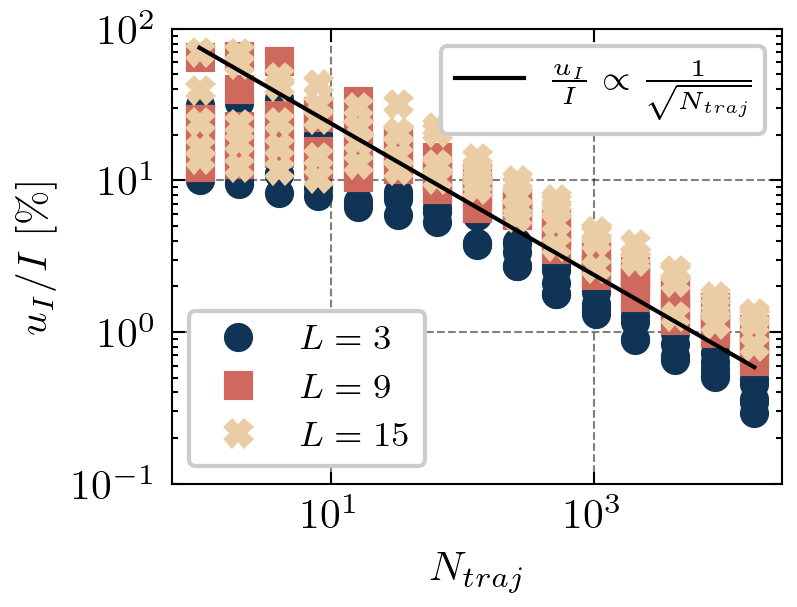

In [55]:
def power_law(x,a,b):
    return a*x**b

T       = 0.1
lip_idx = [0.1,0.6,0.9]
df_tmp  = df.copy()
df_tmp  = df_tmp[df_tmp['T']==T]
marker  = ['o','s','X']

fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)

lines   = []
for j, L in enumerate(L_VALS):
    val     = df_tmp[df_tmp['L']==L]
    line,   = ax.plot(val['Jumps'], 100*val['Error']/val['Observable'], marker[j], label=f'$L = {L}$', color=cmpas.lipari(lip_idx[j]))
    lines.append(line)

leg1 = ax.legend(handles=lines, fontsize='small', loc='lower left')
ax.add_artist(leg1)

line_fit, = ax.plot(M_VALS, power_law(np.array(M_VALS), 75, -0.5), 
                    color='black', label='$\\frac{u_I}{I} \propto \\frac{1}{\sqrt{N_{traj}}}$')

_   = ax.legend(handles=[line_fit], fontsize='small', loc='upper right')
_   = ax.set_xscale('log')
_   = ax.set_yscale('log')
_   = ax.set_xlabel("$N_{traj}$")
_   = ax.set_ylabel("$u_I/I~[\mathrm{\%}]$")
_   = ax.set_ylim(1e-1,1e2)

fig.savefig(f"plots/svg/relative_error_vs_traj_jumps.svg", transparent=True)
fig.savefig(f"plots/pdf/relative_error_vs_traj_jumps.pdf", transparent=False)
fig.savefig(f"plots/png/relative_error_vs_traj_jumps.png", transparent=False)